<a href="https://colab.research.google.com/github/KhanhHa313/Hypothesis_Tests/blob/main/Hypothesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Social Media Usage & Mental Health — Portfolio Project
**Research question:** Does heavy Instagram use predict lower happiness and higher stress, and how does this vary by gender, income, and urban/rural setting?

---

# Phase 1: Setup + Cleanup + EDA

## 1. Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Clean, minimal plot style
sns.set_theme(style = 'whitegrid', palette = 'muted', font_scale = 1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SAMPLE_N  = 50_000   # rows used during development
RANDOM_STATE = 123

print('Libraries loaded!!')

Libraries loaded!!


## 2. Load & Sample Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/instagram_data.csv')

# Sample for fast iteration (will get commentted out for final run)
df_full = df.copy()
df = df.sample(n = SAMPLE_N, random_state = RANDOM_STATE).reset_index(drop=True)

print(f'Working sample: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Full dataset:   {df_full.shape[0]:,} rows')

Working sample: 50,000 rows × 58 columns
Full dataset:   1,547,896 rows


## 3. Data Overview

In [ ]:
# Basic shape & dtypes
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)

Shape: (50000, 58)

Column dtypes:
user_id                             int64
app_name                           object
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                       object
employment_status                  object
education_level                    object
relationship_status                object
has_children                       object
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                       object
smoking                            object
alcohol_frequency                  object
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64

In [ ]:
# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)

if missing.empty:
    print('No missing values found')
else:
    missing_pct = (missing / len(df) * 100).round(2)
    print(pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}))

No missing values found.


In [ ]:
# Summary statistics for key numeric columns
KEY_NUMERIC = [
    'age',
    'perceived_stress_score',
    'self_reported_happiness',
    'daily_active_minutes_instagram',
    'time_on_reels_per_day',
    'sessions_per_day',
    'sleep_hours_per_night',
    'exercise_hours_per_week',
    'body_mass_index',
    'user_engagement_score',
]

df.describe().round(2)

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,...,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,772564.79,39.07,7.14,7.0,19.97,5.48,24.96,124.37,79.44,7999.89,...,37.73,32.92,56.43,2127.56,2586.03,0.50,2017.51,20.59,1.98,1.64
std,447893.97,15.28,4.00,1.1,11.85,2.87,3.97,20.23,11.55,89.49,...,25.55,21.49,35.28,3289.16,2743.85,0.29,4.62,8.71,1.35,1.81
min,6.00,13.00,0.00,3.0,0.00,1.00,15.00,90.00,60.00,7631.00,...,1.00,1.00,1.00,10.00,20.00,0.00,2010.00,5.00,0.00,0.74
25%,384743.50,26.00,4.00,6.3,10.00,3.00,22.30,107.00,70.00,7940.00,...,18.00,16.00,29.00,536.00,658.00,0.25,2013.00,13.40,1.00,1.00
50%,770588.00,39.00,6.60,7.0,20.00,5.00,25.00,124.00,79.00,7999.00,...,34.00,30.00,54.00,1141.00,1501.50,0.50,2018.00,20.50,2.00,1.10
75%,1160754.50,52.00,9.70,7.7,30.00,8.00,27.60,142.00,89.00,8059.00,...,54.00,47.00,80.00,2430.00,3412.00,0.75,2022.00,27.70,3.00,1.29
max,1547878.00,65.00,23.20,10.0,40.00,10.00,43.10,159.00,99.00,8349.00,...,149.00,128.00,208.00,102658.00,10000.00,1.00,2025.00,51.00,5.00,17.50


## 4. Data Cleaning & Feature Engineering

In [ ]:
# Ordered categories
income_order = ['Low', 'Middle', 'Lower-middle', 'Upper-middle', 'High']
edu_order    = ['Other','High school','Some college', 'Bachelor’s', 'Master’s', 'PhD']

df['income_level']    = pd.Categorical(df['income_level'],    categories = income_order, ordered = True)
df['education_level'] = pd.Categorical(df['education_level'], categories = edu_order,    ordered = True)

# Age groups
df['age_group'] = pd.cut(
    df['age'],
    bins = [0, 24, 34, 44, 54, 100],
    labels = ['18–24', '25–34', '35–44', '45–54', '55+']) #exclusive ends

# Heavy user flag (above median daily Instagram minutes)
median_usage = df['daily_active_minutes_instagram'].median()
df['heavy_user'] = (df['daily_active_minutes_instagram'] > median_usage).map({True: 'Heavy', False: 'Light'})

# High stress flag (above median stress score)
median_stress = df['perceived_stress_score'].median()
df['high_stress'] = np.where(df['perceived_stress_score'] > median_stress, "High", "Low")

# Total passive consumption (reels + feed + explore)
df['total_passive_time'] = (
    df['time_on_reels_per_day'] +
    df['time_on_feed_per_day'] +
    df['time_on_explore_per_day']
)

print('New columns added:')
print(df[['age_group', 'heavy_user', 'high_stress', 'total_passive_time']].head(5))

New columns added:
  age_group heavy_user high_stress  total_passive_time
0     25–34      Heavy         Low                 226
1     18–24      Light         Low                 111
2     45–54      Heavy        High                 230
3     18–24      Light         Low                  77
4     45–54      Heavy        High                 285


In [ ]:
# Verify no nulls in key columns
new_cols = ['age_group', 'heavy_user', 'high_stress', 'total_passive_time', 'income_level']
print(df[new_cols].isnull().sum())

age_group             0
heavy_user            0
high_stress           0
total_passive_time    0
income_level          0
dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Outcome variable distributions

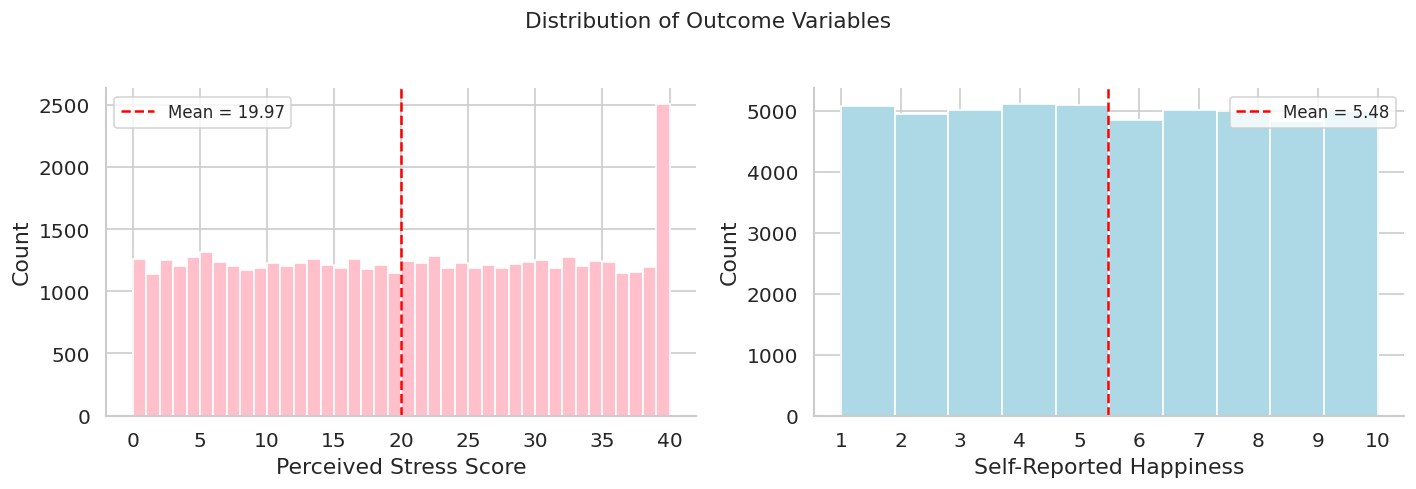


Observation:...


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, label in zip(
    axes,
    ['perceived_stress_score', 'self_reported_happiness'],
    ['pink', 'lightblue'],
    ['Perceived Stress Score', 'Self-Reported Happiness']
):
    ax.hist(df[col].dropna(), bins= np.where(col == 'perceived_stress_score', 40, 10) , color=color, edgecolor='white')
    ax.axvline(df[col].mean(), color = 'red', linestyle = '--', label = f'Mean = {df[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize = 10)

axes[1].set_xticks(np.arange(1, 11)) #set_xticks for ax and xticks funtion for plt

fig.suptitle('Distribution of Outcome Variables', fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.show()


### 5.2 Instagram usage vs stress — heavy vs light users

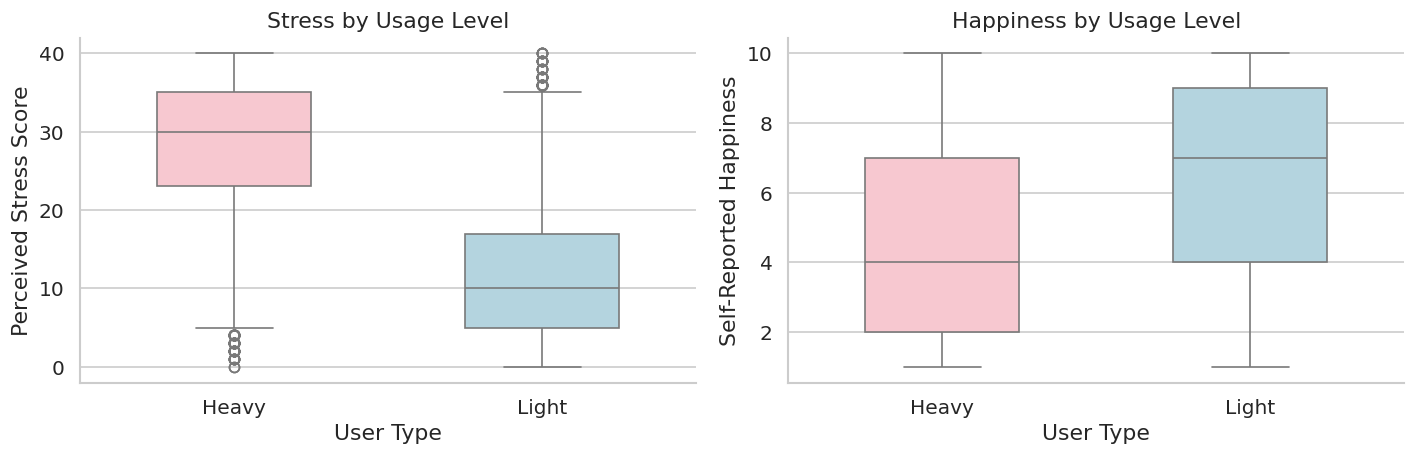


Descriptive Stats over Stress and Happiness:


,perceived_stress_score,self_reported_happiness
heavy_user,,
Heavy,28.73,4.72
Light,11.24,6.23


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

palette = {'Heavy': 'pink', 'Light': 'lightblue'}

# Box plot: stress by heavy/light
sns.boxplot(
    data=df, x='heavy_user', y='perceived_stress_score',
    palette = palette, width = 0.5, ax = axes[0]
)
axes[0].set_xlabel('User Type')
axes[0].set_ylabel('Perceived Stress Score')
axes[0].set_title('Stress by Usage Level')

# Box plot: happiness by heavy/light
sns.boxplot(
    data = df, x = 'heavy_user', y ='self_reported_happiness',
    palette = palette, width = 0.5, ax = axes[1]
)
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Self-Reported Happiness')
axes[1].set_title('Happiness by Usage Level')

plt.tight_layout()
plt.show()

# Quick descriptive stats
print('\nDescriptive Stats over Stress and Happiness:')
df.groupby('heavy_user')[['perceived_stress_score', 'self_reported_happiness']].mean().round(2)

### 5.3 Stress & happiness across income groups

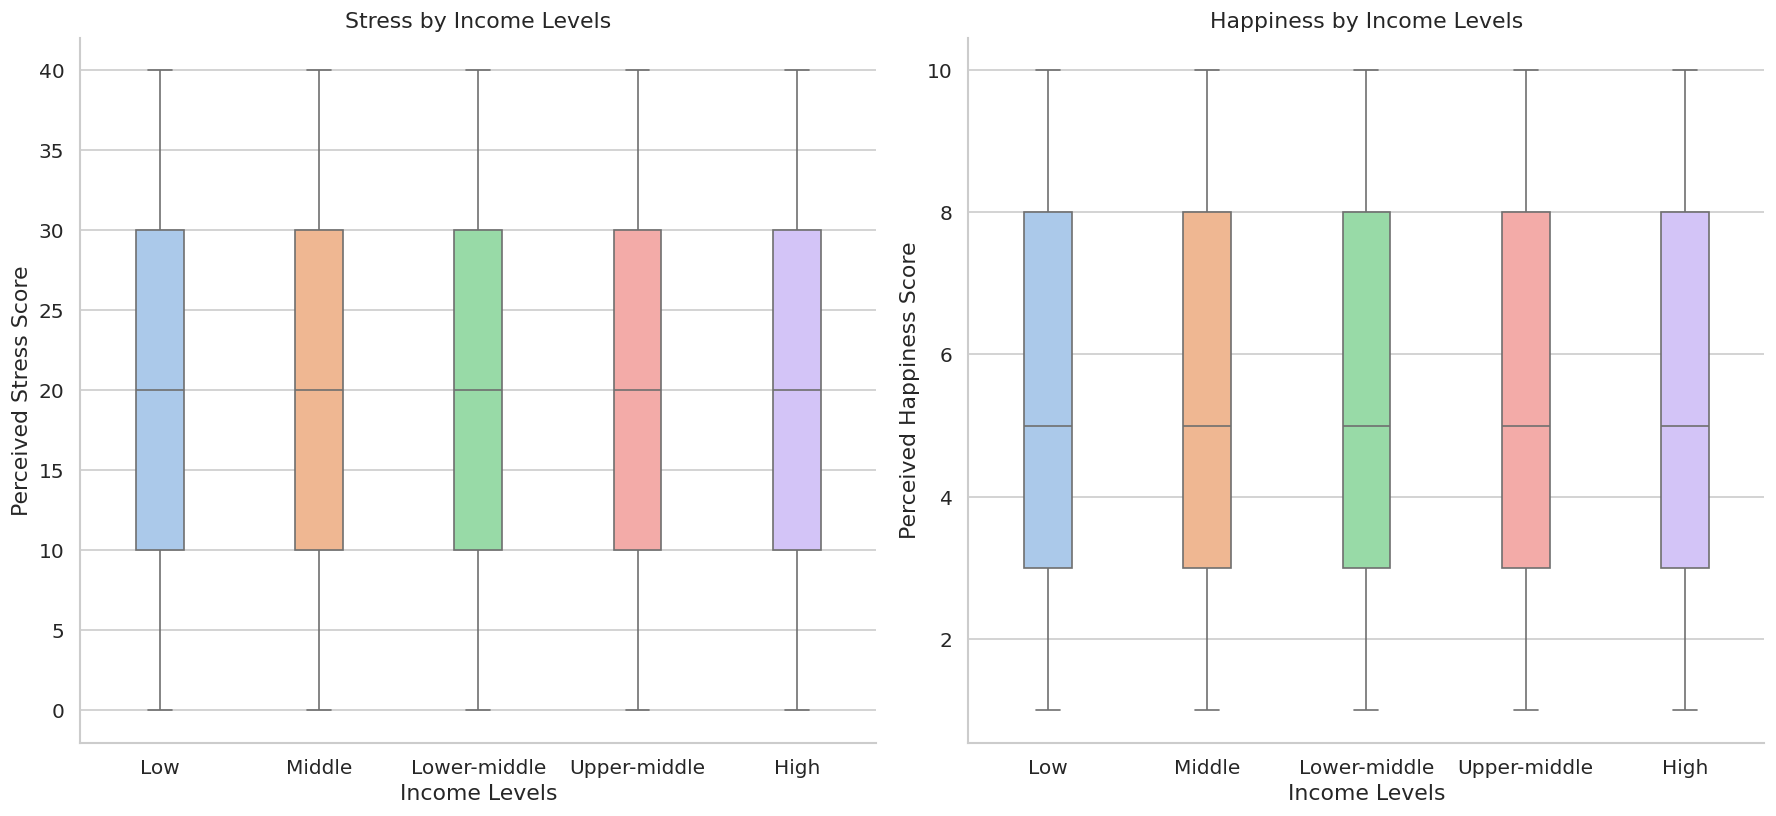


Descriptive Stats over Stress and Happiness:


,perceived_stress_score,self_reported_happiness
income_level,,
Low,20.18,5.45
Middle,19.79,5.51
Lower-middle,20.00,5.47
Upper-middle,19.91,5.44
High,20.09,5.49


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))


# Box plot: stress by income
sns.boxplot(
    data = df,
    x = 'income_level', y = 'perceived_stress_score',
    palette = 'pastel', width = 0.3, ax = axes[0])

axes[0].set_xlabel('Income Levels')
axes[0].set_ylabel('Perceived Stress Score')
axes[0].set_title('Stress by Income Levels')

# Box plot: happiness by income
sns.boxplot(
    data = df,
    x = 'income_level', y = 'self_reported_happiness',
    palette = 'pastel', width = 0.3, ax = axes[1])

axes[1].set_xlabel('Income Levels')
axes[1].set_ylabel('Perceived Happiness Score')
axes[1].set_title('Happiness by Income Levels')


plt.tight_layout()
plt.show()

# Quick descriptive stats
print('\nDescriptive Stats over Stress and Happiness:')
df.groupby('income_level')[['perceived_stress_score', 'self_reported_happiness']].mean().round(2)

### 5.4 Scatter — daily Instagram minutes vs stress (coloured by income)

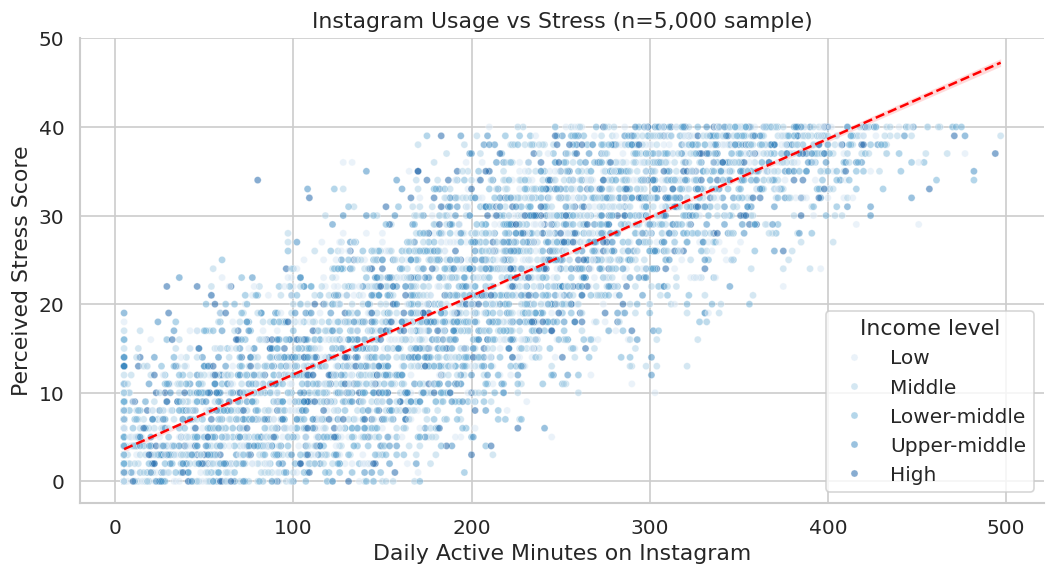

In [ ]:
# Sample 5k points so the scatter isn't overplotted
scatter_df = df.sample(5000, random_state = RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 5))

sns.regplot(
    data=scatter_df,
    x='daily_active_minutes_instagram', y='perceived_stress_score',
    scatter = False, color = 'red',
    line_kws = {'linewidth': 1.5, 'linestyle': '--'}, ax = ax
)

# Regression line across all points
sns.scatterplot(
    data = scatter_df,
    x ='daily_active_minutes_instagram', y='perceived_stress_score',
    hue ='income_level', hue_order = income_order,
    palette ='Blues', alpha = 0.5, s = 18, ax = ax
)

ax.set_xlabel('Daily Active Minutes on Instagram')
ax.set_ylabel('Perceived Stress Score')
ax.set_title('Instagram Usage vs Stress (n=5,000 sample)')
ax.legend(title='Income level')

plt.tight_layout()
plt.show()

### 5.5 Correlation heatmap — usage & wellbeing columns

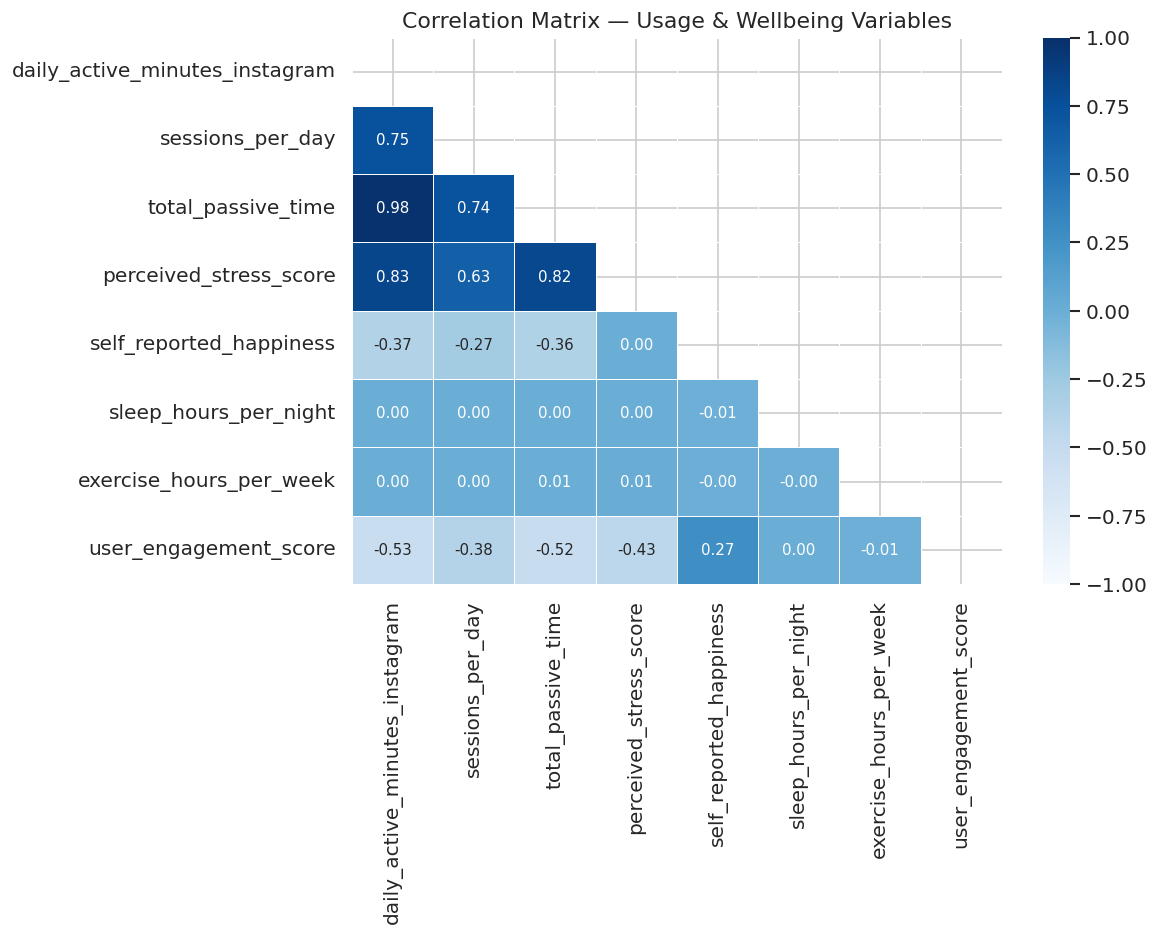


Observation: 


In [ ]:
HEATMAP_COLS = [
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'total_passive_time',
    'perceived_stress_score',
    'self_reported_happiness',
    'sleep_hours_per_night',
    'exercise_hours_per_week',
    'user_engagement_score']

corr = df[HEATMAP_COLS].corr()

mask = np.triu(np.ones_like(corr, dtype = bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(data = corr, mask = mask, cmap = 'Blues', #mask used to hide the hidden cells
            annot = True, fmt = '.2f',annot_kws={'size': 9},
            linewidths=0.3, linecolor = 'white',
            vmin = -1, vmax = 1, center = 0, ax = ax)

ax.set_title('Correlation Matrix — Usage & Wellbeing Variables' )
plt.tight_layout()
plt.show()



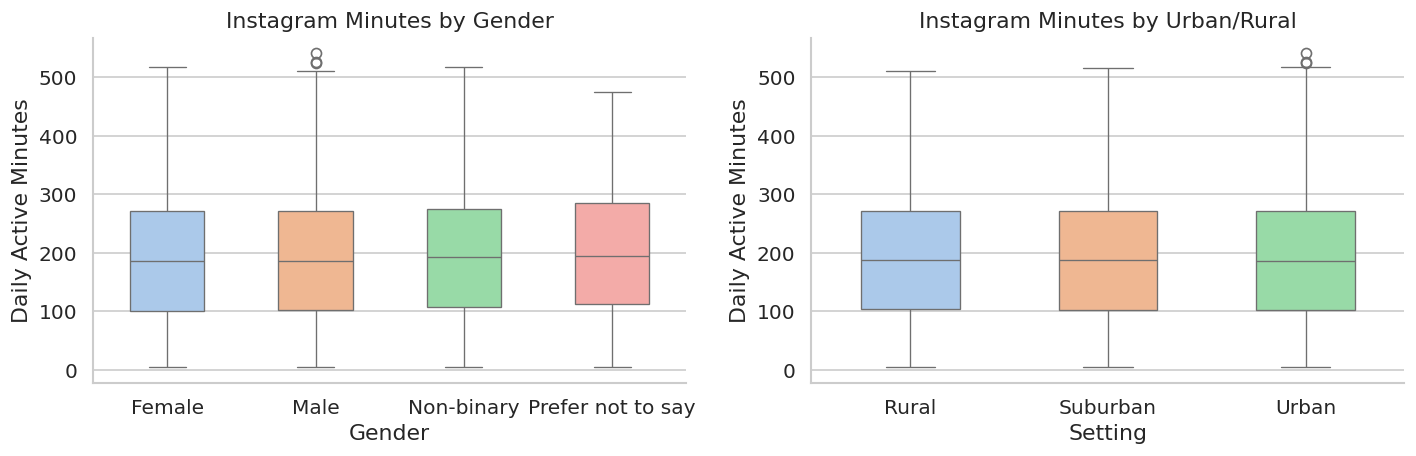

Gender breakdown:
                     count    mean     std  min    25%    50%    75%    max
gender                                                                     
Female             23948.0  187.57  109.97  5.0  101.0  186.0  271.0  517.0
Male               24065.0  188.51  110.20  5.0  102.0  186.0  271.0  541.0
Non-binary          1467.0  192.35  110.99  5.0  107.0  192.0  274.0  518.0
Prefer not to say    520.0  196.07  109.77  5.0  112.0  194.5  285.0  475.0

Urban/Rural breakdown:
               count    mean     std  min     25%    50%    75%    max
urban_rural                                                           
Rural         7483.0  188.94  110.20  5.0  103.00  187.0  272.0  510.0
Suburban     15053.0  188.45  110.28  5.0  102.00  187.0  272.0  515.0
Urban        27464.0  187.96  110.00  5.0  101.75  186.0  271.0  541.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender
sns.boxplot(
    data = df, x ='gender', y ='daily_active_minutes_instagram',
    palette ='pastel', width = 0.5, linewidth = 0.8, ax = axes[0]
)
axes[0].set_title('Instagram Minutes by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Daily Active Minutes')

# Urban vs rural
sns.boxplot(
    data = df, x ='urban_rural', y ='daily_active_minutes_instagram',
    palette ='pastel', width = 0.5, linewidth = 0.8, ax = axes[1]
)
axes[1].set_title('Instagram Minutes by Urban/Rural')
axes[1].set_xlabel('Setting')
axes[1].set_ylabel('Daily Active Minutes')

plt.tight_layout()
plt.show()

# Summary table
print('Gender breakdown:')
print(df.groupby('gender')['daily_active_minutes_instagram'].describe().round(2))
print('\nUrban/Rural breakdown:')
print(df.groupby('urban_rural')['daily_active_minutes_instagram'].describe().round(2))

## 6. Phase 1 Summary

**Dataset:** 50,000-row working sample from 1.5M rows across ~60 columns.

**Key observations from EDA:**
- No concerning outliers or missing (null) values were found in the dataset
- The stress scores of heavy social media users are noticeably higher than those of light users, with a substantial difference between the two groups
- There is no noticeable difference in average social media usage across different socioeconomic groups
- The correlation matrix indicates that stress levels are strongly positively correlated with social media usage, while happiness is moderately negatively correlated with social media usage



# Phase 2: Testings 4 Hypothesis

## Hypothesis 1 — Do heavy Instagram users report higher stress than light users?

| | |
|---|---|
| **H0** | Mean stress score is equal for heavy and light Instagram users |
| **H1** | Heavy users report a higher mean stress score than light users |
| **Significance level** | α = 0.05 |
| **Tail** | One-tailed (we expect heavy > light) |

In [ ]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.8 MB/s eta 0:00:00


In [ ]:
import pingouin as pg

In [ ]:
heavy = df[df['heavy_user'] == 'Heavy']['perceived_stress_score'].dropna()
light = df[df['heavy_user'] == 'Light']['perceived_stress_score'].dropna()

print(f"Heavy users : n = {len(heavy):,}  mean = {heavy.mean():.3f}  std = {heavy.std():.3f}")
print(f"Light users : n = {len(light):,}  mean = {light.mean():.3f}  std = {light.std():.3f}")
print(f"\nMean difference (heavy - light): {heavy.mean() - light.mean():.3f}")

Heavy users : n = 24,953  mean = 28.733  std = 7.998
Light users : n = 25,047  mean = 11.238  std = 7.980

Mean difference (heavy - light): 17.496


### Check normality (justifies parametric vs non-parametric choice)

In [ ]:
# With n > 1000 Shapiro-Wilk is too sensitive, so we use D'Agostino-Pearson

stat_h, p_h = stats.normaltest(heavy)
stat_l, p_l = stats.normaltest(light)

print("D'Agostino-Pearson normality test:")
print(f"  Heavy users : test statistics = {stat_h:.3f}, p-value = {p_h:.4f} → {'NOT normal' if p_h < 0.05 else 'normal'}")
print(f"  Light users : test statistics = {stat_h:.3f}, p-value = {p_l:.4f} → {'NOT normal' if p_l < 0.05 else 'normal'}")
print()
# print("We run both parametric and non-parametric tests and compare conclusions.")

D'Agostino-Pearson normality test:
  Heavy users : test statistics = 1427.463, p-value = 0.0000 → NOT normal
  Light users : test statistics = 1427.463, p-value = 0.0000 → NOT normal



Text(0.5, 1.05, 'Normality Check — Stress Score by User Group')

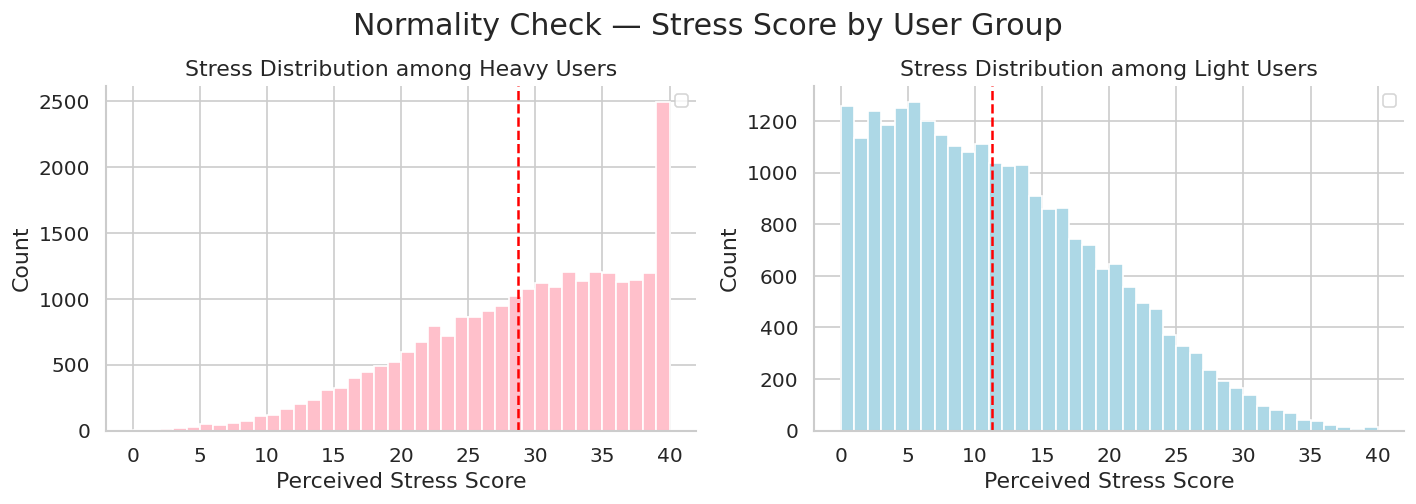

In [ ]:
# Visual check

fig, axes = plt.subplots(1, 2, figsize = (12,4))

for ax, group, color, label in zip (axes, [heavy, light],
                             ['pink', 'lightblue'],
                            ['Heavy Users', 'Light Users']):
    ax.hist(group, bins = 40, color = color)
    ax.axvline(x=group.mean(), color='red', linestyle='--')
    ax.set_title(f'Stress Distribution among {label}')
    ax.set_xlabel('Perceived Stress Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.tight_layout()
fig.suptitle ("Normality Check — Stress Score by User Group", y = 1.05, fontsize = 18)


In [ ]:
# Levene's test for equal variances first
lev_stat, lev_p = stats.levene(heavy, light)
equal_var = lev_p > 0.05
print(f"Levene's test: stat = {lev_stat:.3f}, p = {lev_p:.4f}")
print(f"--> Variances are {'equal — use standard t-test' if equal_var else 'unequal — use Welch t-test (equal_var = False)'}")
print()

# Independent t-test
t_stat, p_ttest = stats.ttest_ind(heavy, light,
                                  equal_var = equal_var,
                                  alternative = 'greater')

# Cohen's d effect size
pooled_std = np.sqrt((heavy.std()**2 + light.std()**2) / 2)
cohens_d = (heavy.mean() - light.mean()) / pooled_std

print("Independent t-test (one-tailed):")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_ttest:.4f}")
print(f"  Cohen's d   : {cohens_d:.4f}")
print()

# Interpret effect size
if   abs(cohens_d) < 0.2: effect = 'small'
elif abs(cohens_d) < 0.5: effect = 'medium'
elif abs(cohens_d) < 0.8: effect = 'large'
else:                      effect = 'very large'

conclusion = 'REJECT H0' if p_ttest < 0.05 else 'FAIL TO REJECT H0'
print(f"Decision: {conclusion} (alpha = 0.05)")
print(f"Effect size: {effect} (d = {cohens_d:.3f})")

Levene's test: stat = 0.001, p = 0.9815
→ Variances are equal — use standard t-test

Independent t-test (one-tailed):
  t-statistic : 244.8426
  p-value     : 0.0000
  Cohen's d   : 2.1899

Decision: REJECT H0 (alpha = 0.05)
Effect size: very large (d = 2.190)


In [ ]:
# Mann-Whitney U test (one-tailed)
u_stat, p_mw = stats.mannwhitneyu(heavy, light, alternative = 'greater')

# Rank-biserial correlation as effect size for Mann-Whitney
n1, n2 = len(heavy), len(light)
rank_biserial = abs(1 - (2 * u_stat) / (n1 * n2))

print("Mann-Whitney U test (one-tailed):")
print(f"  U-statistic       : {u_stat:.1f}")
print(f"  p-value           : {p_mw:.4f}")
print(f"  Rank-biserial r   : {rank_biserial:.4f}") #disregard the U orientation
print(f"  Heavy median      : {heavy.median():.3f}")
print(f"  Light median      : {light.median():.3f}")
print()

conclusion_mw = 'REJECT H0' if p_mw < 0.05 else 'FAIL TO REJECT H0'
print(f"Decision: {conclusion_mw} (alpha = 0.05)")
print(f"Effect size: {'large' if rank_biserial >= 0.8 else 'medium' if rank_biserial >= 0.5 else 'small'} (d = {rank_biserial:.3f})")

Mann-Whitney U test (one-tailed):
  U-statistic       : 578814067.5
  p-value           : 0.0000
  Rank-biserial r   : 0.8522
  Heavy median      : 30.000
  Light median      : 10.000

Decision: REJECT H0 (alpha = 0.05)
Effect size: large (d = 0.852)


In [ ]:
np.random.seed(RANDOM_STATE)
n_bootstrap = 5000
boot_diffs = [
    np.random.choice(heavy, size = len(heavy), replace = True).mean() -
    np.random.choice(light, size = len(light), replace = True).mean()
    for _ in range(n_bootstrap)]

ci_low  = np.percentile(boot_diffs, 2.5)
ci_high = np.percentile(boot_diffs, 97.5)
obs_diff = heavy.mean() - light.mean()

print(f"Bootstrap 95% CI for mean difference (heavy - light):")
print(f"  Observed difference : {obs_diff:.4f}")
print(f"  95% CI              : [{ci_low:.4f}, {ci_high:.4f}]")
print()
print("Interpretation: we are 95% confident the true difference in mean stress")
print(f"between heavy and light users falls between {ci_low:.3f} and {ci_high:.3f}.")
if ci_low > 0:
    print("Since the CI does not cross 0, the difference is statistically significant.")
else:
    print("Since the CI crosses 0, the difference is not statistically significant.")

Bootstrap 95% CI for mean difference (heavy - light):
  Observed difference : 17.4957
  95% CI              : [17.3559, 17.6418]

Interpretation: we are 95% confident the true difference in mean stress
between heavy and light users falls between 17.356 and 17.642.
Since the CI does not cross 0, the difference is statistically significant.


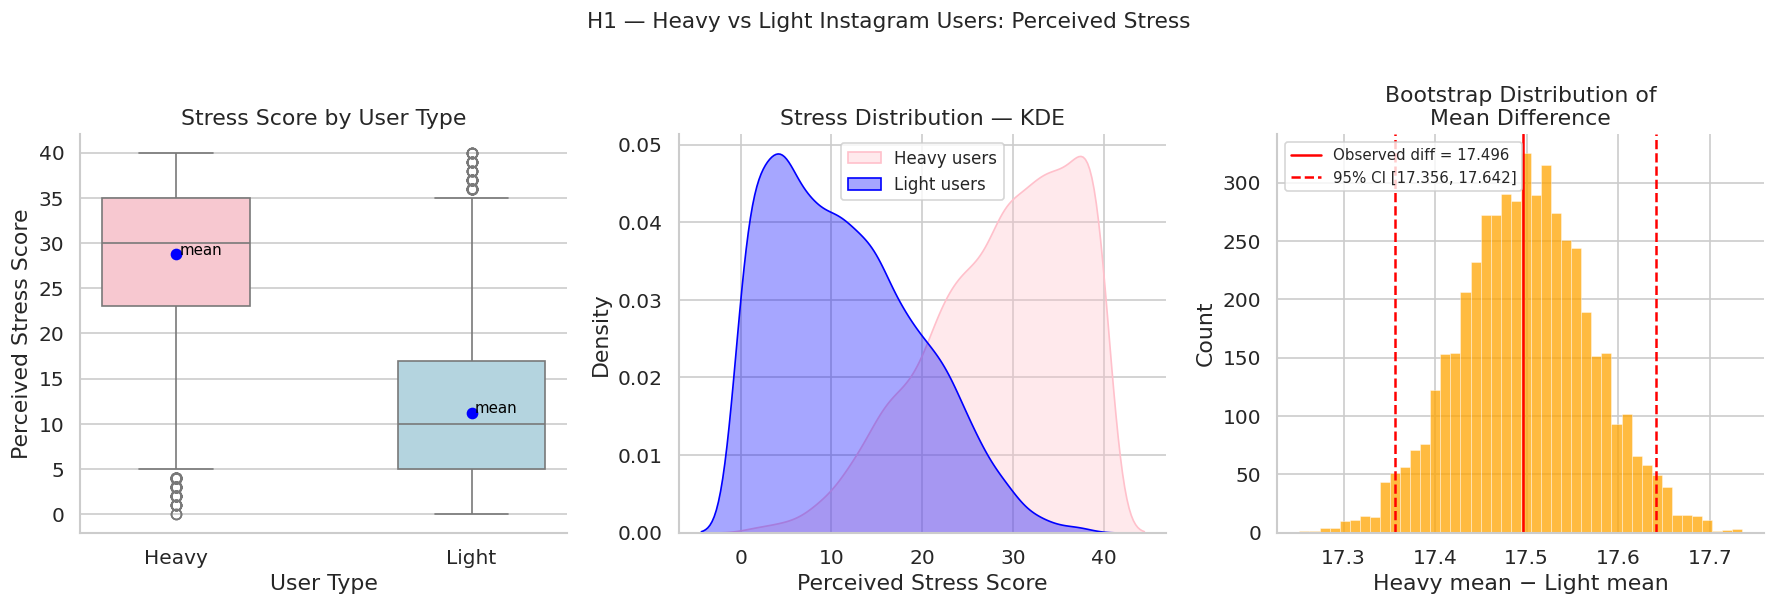

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Box plot with means ---
plot_df = df[['heavy_user', 'perceived_stress_score']].dropna()
sns.boxplot(
    data = plot_df, x ='heavy_user', y = 'perceived_stress_score',
    palette ={'Heavy': 'pink', 'Light': 'lightblue'},
    width = 0.5, ax = axes[0]
)
# Overlay mean markers
means = plot_df.groupby('heavy_user')['perceived_stress_score'].mean()

for i, group in enumerate(['Heavy', 'Light']):
    axes[0].plot(i, means[group], marker = 'o', markersize = 6, color = 'blue')
    axes[0].annotate('mean', xy=(i + 0.01, means[group]), fontsize = 9, color = 'black')


axes[0].set_title('Stress Score by User Type')
axes[0].set_xlabel('User Type')
axes[0].set_ylabel('Perceived Stress Score')

# --- Plot 2: Overlapping KDE ---
for group, color, label in [('Heavy', 'pink', 'Heavy users'), ('Light', 'blue', 'Light users')]:
    subset = df[df['heavy_user'] == group]['perceived_stress_score'].dropna().sample(5000, random_state = RANDOM_STATE)
    sns.kdeplot(subset, ax = axes[1], color = color, fill = True, alpha = 0.35, label = label)
axes[1].set_title('Stress Distribution — KDE')
axes[1].set_xlabel('Perceived Stress Score')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize = 10)

# --- Plot 3: Bootstrap distribution ---
axes[2].hist(boot_diffs, bins ='fd', color ='orange', alpha = 0.75, edgecolor = 'white', linewidth = 0.3)
axes[2].axvline(obs_diff, color ='red', linestyle ='-', label =f'Observed diff = {obs_diff:.3f}')
axes[2].axvline(ci_low, color ='red', linestyle ='--', label =f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
axes[2].axvline(ci_high, color ='red', linestyle ='--')
axes[2].set_title('Bootstrap Distribution of\nMean Difference')
axes[2].set_xlabel('Heavy mean − Light mean')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize = 9)

fig.suptitle('H1 — Heavy vs Light Instagram Users: Perceived Stress', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame({
    'Test'       : ['Independent t-test', 'Mann-Whitney U', 'Bootstrap 95% CI'],
    'Statistic'  : [f't = {t_stat:.4f}', f'U = {u_stat:.1f}', f'obs_diff = {obs_diff:.4f}'],
    'p-value'    : [f'{p_ttest:.4f}', f'{p_mw:.4f}', '-'],
    'Effect size': [f"Cohen's d = {cohens_d:.4f} ({effect})", f'r = {rank_biserial:.4f}', f'[{ci_low:.4f}, {ci_high:.4f}]'],
    'Decision'   : [
        'Reject H0' if p_ttest < 0.05 else 'Fail to reject H0',
        'Reject H0' if p_mw    < 0.05 else 'Fail to reject H0',
        'Significant' if ci_low > 0 else 'Not significant'
    ]
})

results.set_index('Test', inplace=True)
results

,Statistic,p-value,Effect size,Decision
Test,,,,
Independent t-test,t = 244.8426,0.0000,Cohen's d = 2.1899 (very large),Reject H0
Mann-Whitney U,U = 578814067.5,0.0000,r = 0.8522,Reject H0
Bootstrap 95% CI,obs_diff = 17.4957,-,"[17.3559, 17.6418]",Significant


## Hypothesis 2 — Does overall Instagram time (sessions, feed, explore) jointly predict stress?

| | |
|---|---|
| **H0** | These predictors do not predict the stress, have no correlation with stress level |
| **H1** | These predictors predict the stress, have either negative or positive correlation with stress level |
| **Significance level** | α = 0.05 |
| **Tail** | Two-tailed |

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
model = smf.ols('perceived_stress_score ~ sessions_per_day + time_on_feed_per_day + time_on_explore_per_day', data = df).fit()

print(f"\n{'='*90}")
print(f"  R²          : {model.rsquared:.4f}")
print(f"  Adjusted R² : {model.rsquared_adj:.4f}")
print(f"  F p-value   : {model.f_pvalue:.4e}")
print(f"{'='*90}")
print(model.summary())


  R²          : 0.6679
  Adjusted R² : 0.6679
  F p-value   : 0.0000e+00
                              OLS Regression Results                              
Dep. Variable:     perceived_stress_score   R-squared:                       0.668
Model:                                OLS   Adj. R-squared:                  0.668
Method:                     Least Squares   F-statistic:                 3.351e+04
Date:                    Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                            05:44:21   Log-Likelihood:            -1.6699e+05
No. Observations:                   50000   AIC:                         3.340e+05
Df Residuals:                       49996   BIC:                         3.340e+05
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----

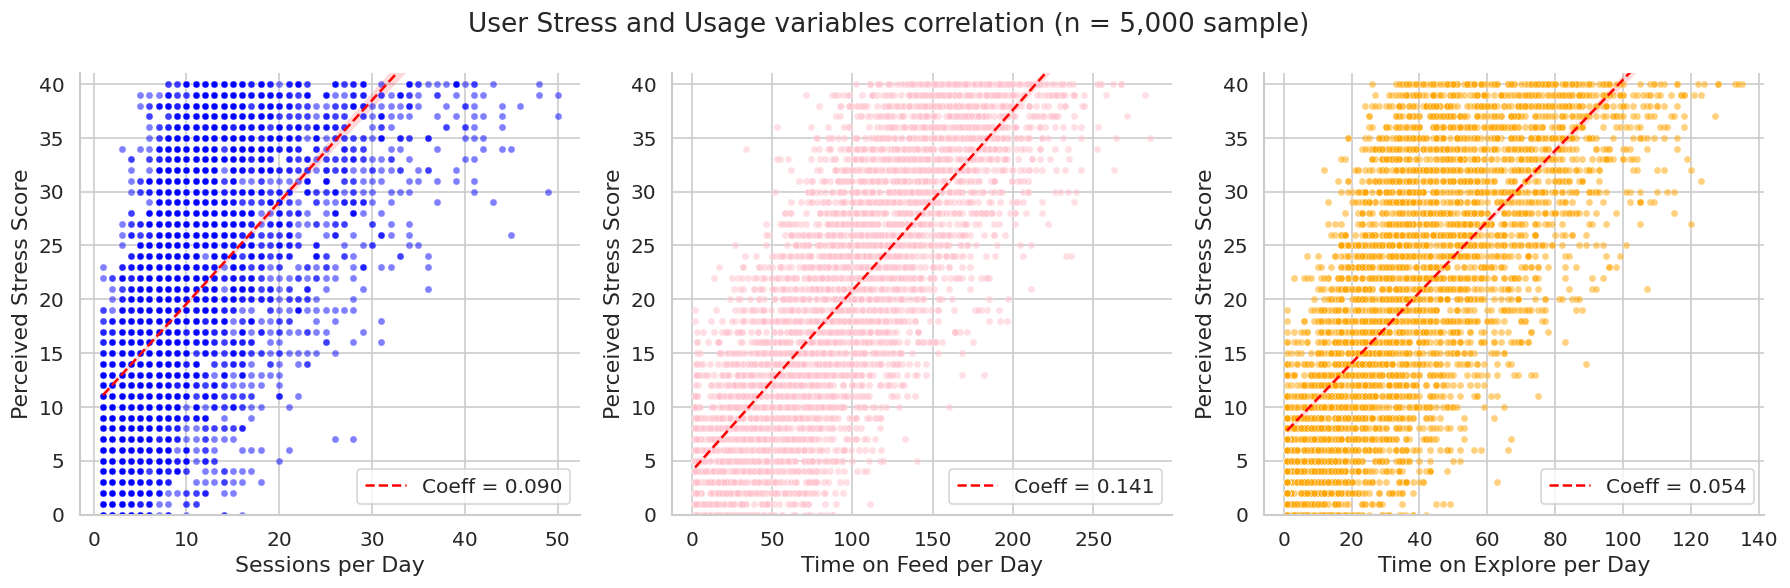

In [ ]:
scatter_df = df.sample(5000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, var, label in zip(axes, ['blue', 'pink', 'orange'],
                               ['sessions_per_day', 'time_on_feed_per_day', 'time_on_explore_per_day'],
                              ['Sessions per Day', 'Time on Feed per Day', 'Time on Explore per Day']):
    sns.regplot(
        data=scatter_df,
        x= var, y = 'perceived_stress_score',
        scatter = False, color = 'red',
        line_kws = {'linewidth': 1.5, 'linestyle': '--'}, ax = ax,
        label=f'Coeff = {model.params[var]:.3f}'
    )
    # Regression line
    sns.scatterplot(
        data = scatter_df,
        x= var, y = 'perceived_stress_score',
        color = col, alpha = 0.5, s = 18, ax = ax
    )
    ax.set_ylim(0, 41)
    ax.set_xlabel(label)
    ax.set_ylabel('Perceived Stress Score')
    ax.legend()

plt.suptitle('User Stress and Usage variables correlation (n = 5,000 sample)')
plt.tight_layout()

                           coef    ci_low   ci_high  significant   color
Sessions / day         0.090012  0.078760  0.101264         True  orange
Time on feed / day     0.140512  0.138290  0.142735         True  orange
Time on explore / day  0.054413  0.049983  0.058843         True  orange


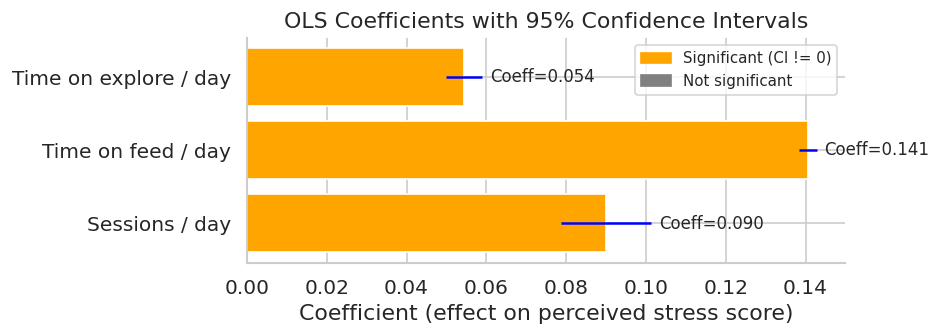

In [ ]:
# Extract coefficients and CIs (exclude intercept)
coef_df = pd.DataFrame({
    'coef'    : model.params,
    'ci_low'  : model.conf_int()[0],
    'ci_high' : model.conf_int()[1],
}).drop('Intercept')

coef_df.index = ['Sessions / day', 'Time on feed / day', 'Time on explore / day']
coef_df['significant'] = ~((coef_df['ci_low'] < 0) & (coef_df['ci_high'] > 0))
coef_df['color'] = coef_df['significant'].map({True: 'orange', False: 'grey'})
print(coef_df)

fig, ax = plt.subplots(figsize=(8, 3))

for i, (idx, row) in enumerate(coef_df.iterrows()):
    ax.barh(i, row['coef'], color = row['color'])
    ax.errorbar(
        x = row['coef'], y = i,
        xerr = [[row['coef'] - row['ci_low']], [row['ci_high'] - row['coef']]],
        color = 'blue')

    ax.text(row['ci_high'] + 0.002, i, f"Coeff = {row['coef']:.3f}", va ='center', fontsize=10)

ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df.index)
ax.set_xlabel('Coefficient (effect on perceived stress score)')
ax.set_title('OLS Coefficients with 95% Confidence Intervals', fontweight='500')

# Legend
from matplotlib.patches import Patch
ax.legend(handles =[
    Patch(color ='orange',  label ='Significant (CI != 0)'),
    Patch(color ='grey', label ='Not significant')
], fontsize=9)

plt.tight_layout()
plt.show()

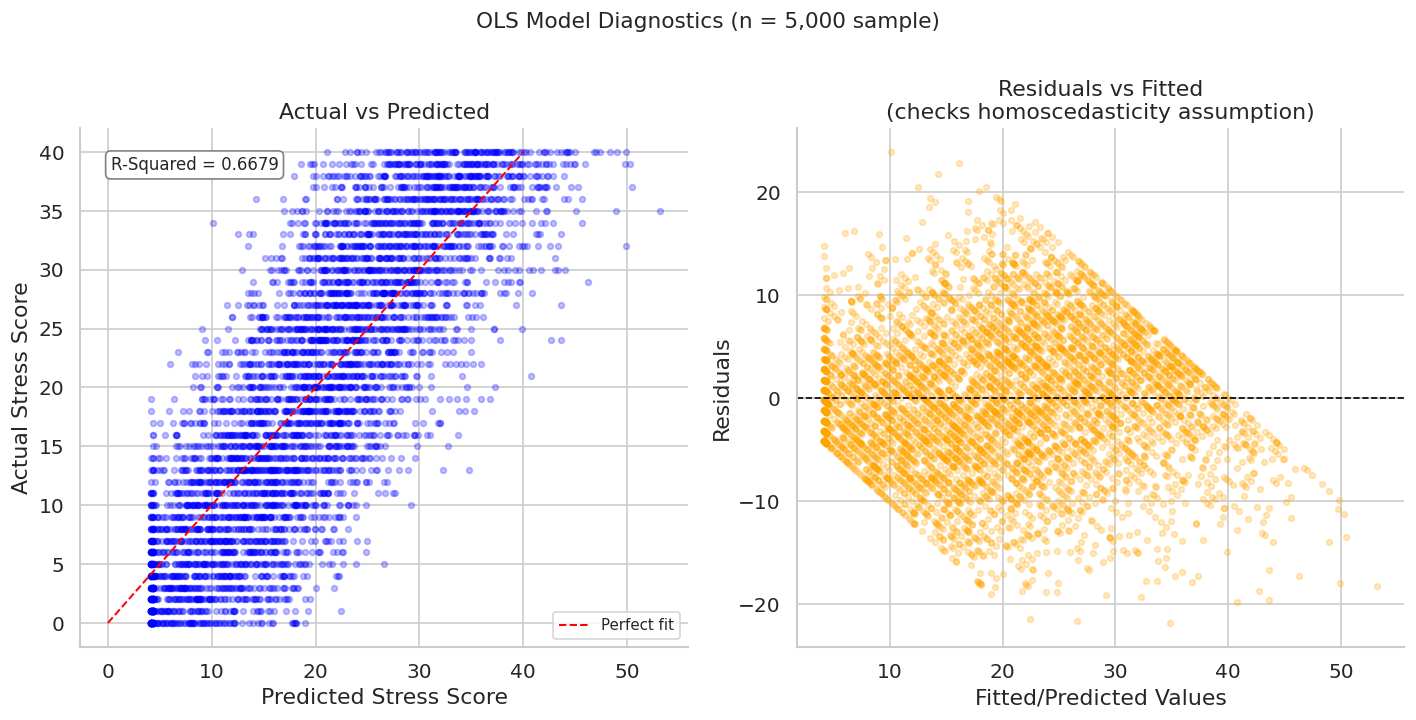

In [ ]:
pred_df = scatter_df.copy()
pred_df['predicted'] = model.predict(pred_df)
pred_df['residual']  = pred_df['perceived_stress_score'] - pred_df['predicted']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Actual vs Predicted ---
axes[0].scatter(pred_df['predicted'], pred_df['perceived_stress_score'],
                alpha = 0.25, s = 12, color = 'blue')
lims = [pred_df['perceived_stress_score'].min(), pred_df['perceived_stress_score'].max()]
axes[0].plot(lims, lims, '--', color = 'red', linewidth = 1.2, label = 'Perfect fit')

axes[0].set_xlabel('Predicted Stress Score')
axes[0].set_ylabel('Actual Stress Score')
axes[0].set_title('Actual vs Predicted')
axes[0].legend(fontsize = 9)
axes[0].annotate(f'R-Squared = {model.rsquared:.4f}', xy = (0.05, 0.92),
                 xycoords = 'axes fraction', fontsize=10,
                 bbox = dict(boxstyle='round,pad=0.3', facecolor ='white', edgecolor='grey'))

# --- Residuals vs Fitted ---
axes[1].scatter(pred_df['predicted'], pred_df['residual'],
                alpha = 0.25, s = 12, color = 'orange')
axes[1].axhline(0, color ='black', linewidth =1, linestyle='--')

axes[1].set_xlabel('Fitted/Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted\n(checks homoscedasticity assumption)')

fig.suptitle('OLS Model Diagnostics (n = 5,000 sample)', fontsize = 13, fontweight = '500', y = 1)
plt.tight_layout()
plt.show()

---
## Hypothesis 3 — Does adding age improve the model's ability to predict stress?

| | |
|---|---|
| **H0** | Age does not add explanatory power beyond Instagram usage variables |
| **H1** | Age significantly improves model fit when combined with usage variables |
| **Method** | Model comparison (OLS) R² and Adjusted R² across nested models |
| **alpha** | 0.05 |

In [ ]:
# Model 1: usage only
m1 = smf.ols('perceived_stress_score ~ total_passive_time', data=df).fit()

# Model 2: usage + age
m2 = smf.ols('perceived_stress_score ~ total_passive_time + age', data=df).fit()

# Summary comparison table
model_comparison = pd.DataFrame({
    'Model': ['M1: Usage only','M2: Usage + Age'],
    'R²': [m1.rsquared, m2.rsquared],
    'Adj R²': [m1.rsquared_adj, m2.rsquared_adj],
    'AIC' : [m1.aic, m2.aic],
    'F p-value': [m1.f_pvalue, m2.f_pvalue]})

model_comparison.set_index('Model')

,R²,Adj R²,AIC,F p-value
Model,,,,
M1: Usage only,0.669837,0.669830,333695.991896,0.0
M2: Usage + Age,0.696380,0.696368,329507.416592,0.0


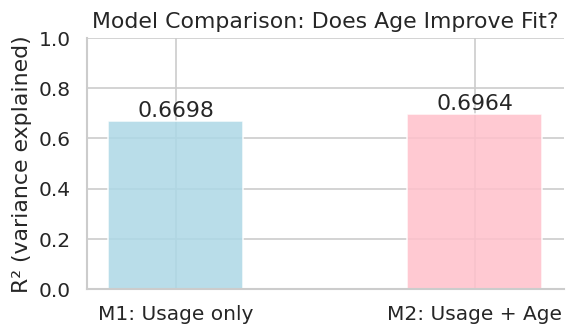

In [ ]:
labels  = ['M1: Usage only', 'M2: Usage + Age' ]
r2_vals = [m1.rsquared, m2.rsquared ]
colors  = ['lightblue', 'pink' ]

fig, ax = plt.subplots(figsize = (5, 3))
bars = ax.bar(labels, r2_vals, color = colors, alpha = 0.85, width = 0.45, edgecolor='white')

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha = 'center', va = 'bottom', fontweight = '500')

ax.set_ylabel('R² (variance explained)')
ax.set_title('Model Comparison: Does Age Improve Fit?')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

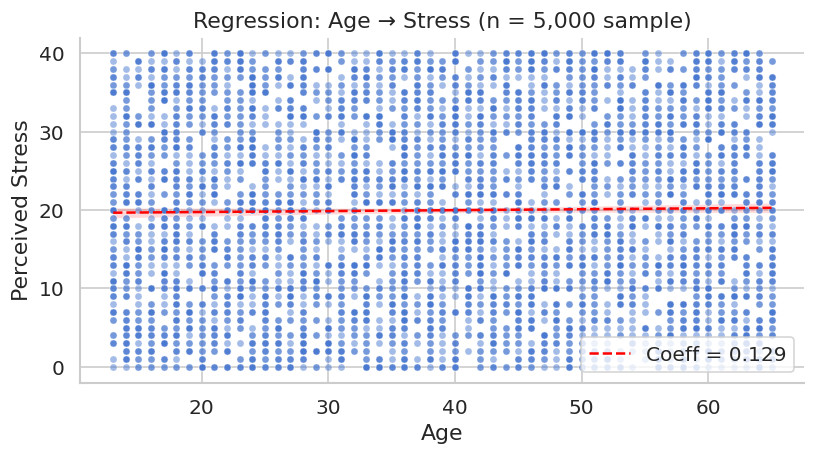

In [ ]:
scatter_df = df.sample(5000, random_state = RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 4))

sns.regplot(
    data=scatter_df,
    x= 'age', y = 'perceived_stress_score',
    scatter = False, color = 'red',
    line_kws = {'linewidth': 1.5, 'linestyle': '--'}, ax = ax,
    label = f'Coeff = {m2.params['age']:.3f}')

sns.scatterplot(
    data=scatter_df,
    x= 'age', y = 'perceived_stress_score',
    alpha = 0.5, s = 18, ax = ax)

ax.set_xlabel('Age')
ax.set_ylabel('Perceived Stress')
ax.set_title('Regression: Age → Stress (n = 5,000 sample)')

plt.tight_layout()
plt.show()


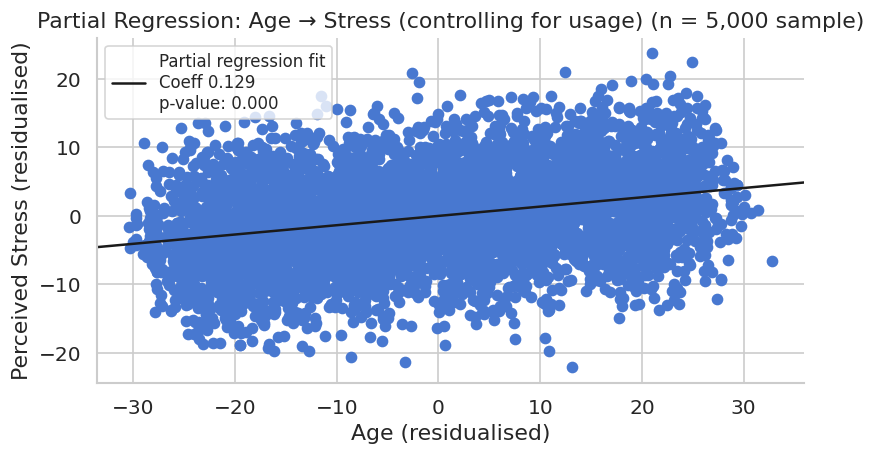

Age alone R-Squared: 0.0000
Usage + Age R-Squared: 0.696

  age_group    mean    sem
0     18–24  20.030  0.112
1     25–34  19.699  0.122
2     35–44  20.048  0.120
3     45–54  20.112  0.122
4       55+  19.942  0.116


In [ ]:
# Partial regression plot shows age's relationship with stress
# AFTER removing the shared variance with other predictors
# This solves the 'messy scatter' problem from a raw age vs stress plot
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(7, 4))
sm.graphics.plot_partregress(
    endog ='perceived_stress_score', exog_i = 'age',
    exog_others = ['total_passive_time'], data = scatter_df,
    obs_labels = False, ax = ax)

ax.lines[1].set_label(f"Partial regression fit\nCoeff {m2.params['age']:.3f}\np-value: {m2.pvalues['age']:.3f}")
ax.set_xlabel('Age (residualised)')
ax.set_ylabel('Perceived Stress (residualised)')
ax.set_title('Partial Regression: Age → Stress (controlling for usage) (n = 5,000 sample)')
ax.legend(fontsize = 10)

plt.tight_layout()
plt.show()

print(f"Age alone R-Squared: {smf.ols('perceived_stress_score ~ age', data = df).fit().rsquared:.4f}")
print(f"Usage + Age R-Squared: {m2.rsquared:.3f}")

print (f'\n{df.groupby('age_group')['perceived_stress_score'].agg(['mean', 'sem']).reset_index().round(3)}')


---
## Hypothesis 4 — Do socioeconomic factors (income, education, employment) affect stress?

| | |
|---|---|
| **H0** | Perceived stress does not differ across income, education, or employment groups |
| **H1** | At least one group differs significantly in perceived stress |
| **Method** | Kruskal-Wallis test + pairwise post-hoc (Holm correction) |
| **Rationale** | Stress scores are right-skewed → non-parametric test preferred over ANOVA |
| **alpha** | 0.05 |

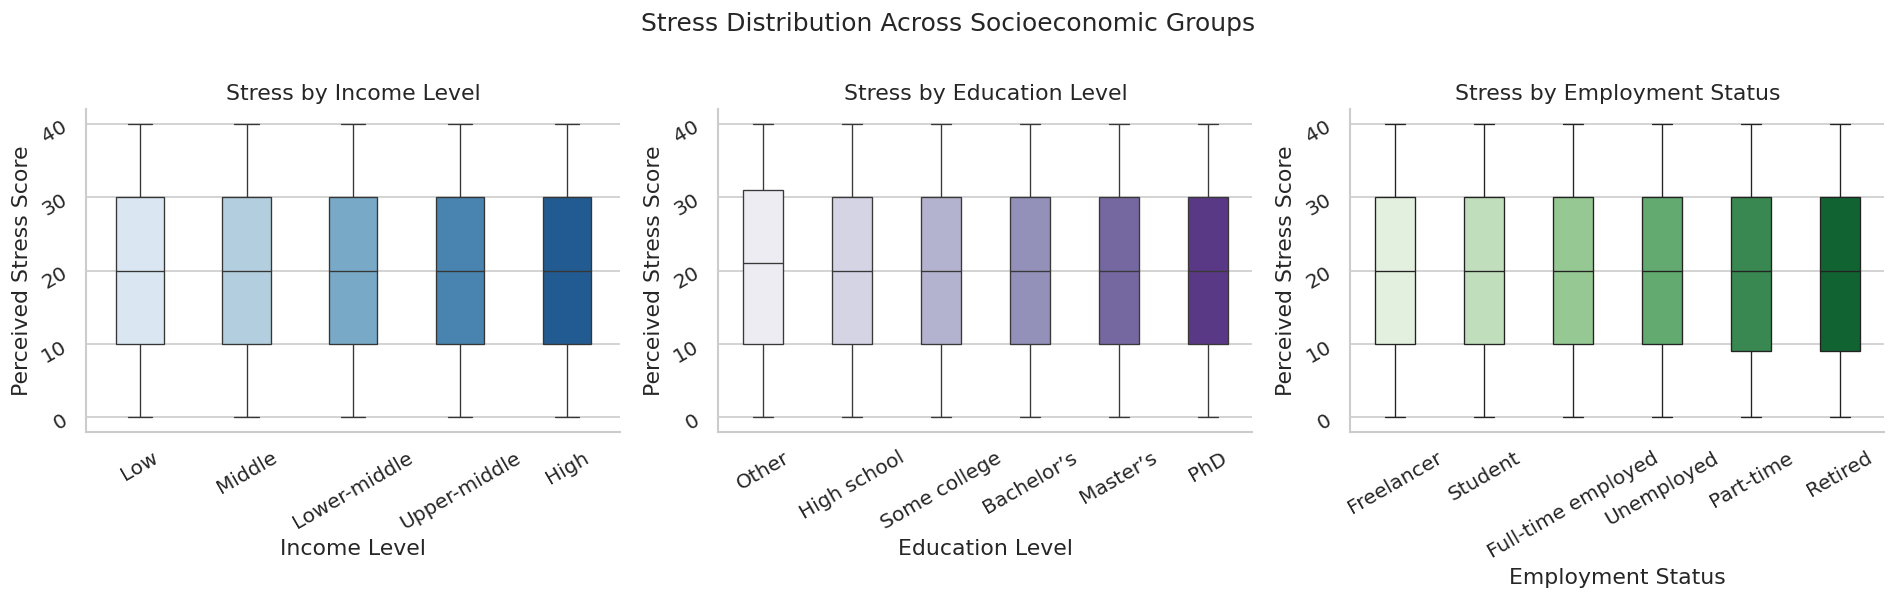

In [ ]:
cat_vars = [
    ('income_level','Income Level','Blues'),
    ('education_level', 'Education Level', 'Purples'),
    ('employment_status', 'Employment Status','Greens')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label, pal) in zip(axes, cat_vars):
    sns.boxplot(
        data = df, x = col, y = 'perceived_stress_score', palette = pal,
        width = 0.45, linewidth = 0.8, ax = ax, showfliers = True,
        flierprops = dict(marker = '.', markersize = 2, alpha = 0.3))

    ax.set_xlabel(label)
    ax.set_ylabel('Perceived Stress Score')
    ax.set_title(f'Stress by {label}')
    ax.tick_params(labelrotation = 30)

fig.suptitle('Stress Distribution Across Socioeconomic Groups', fontsize = 15, fontweight='500', y=1)
plt.tight_layout()
plt.show()

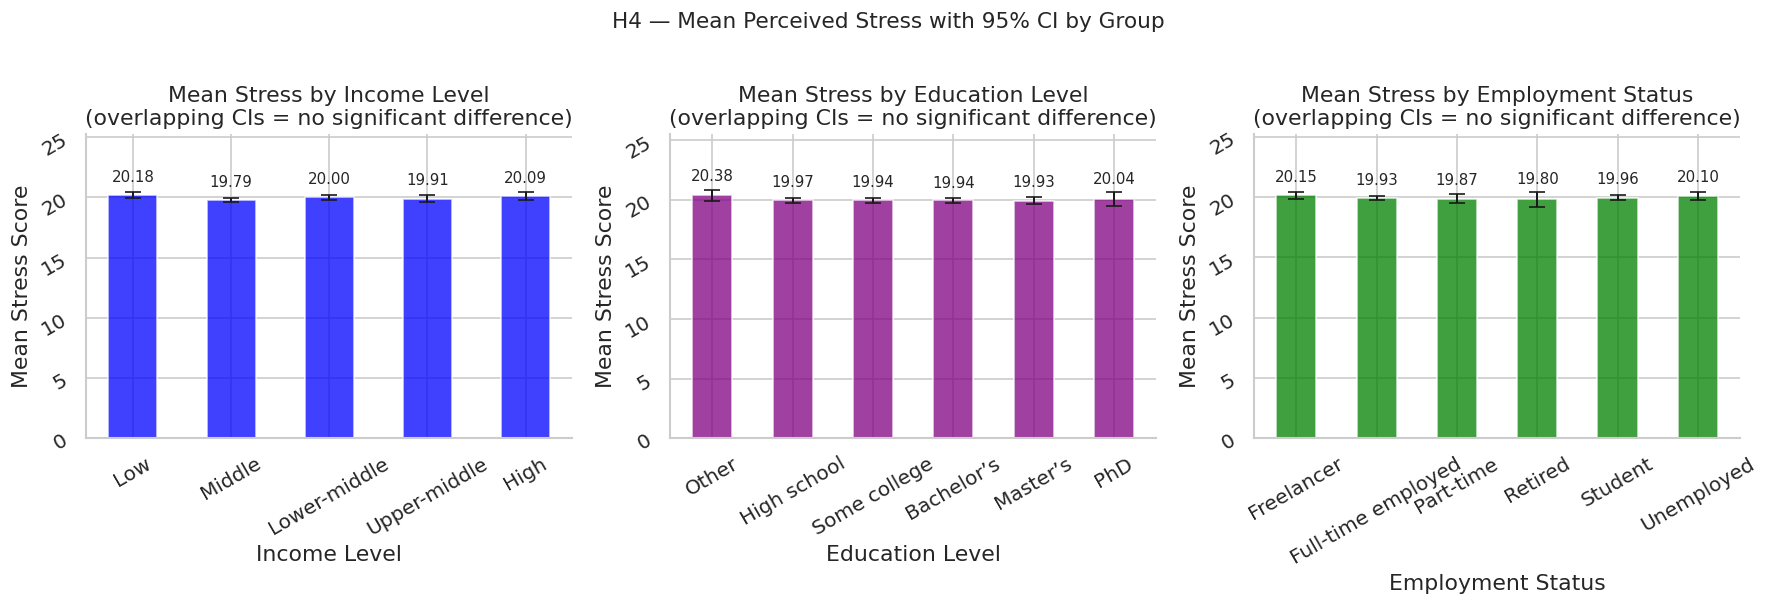

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
colors = ['blue', 'purple', 'green']

for ax, (col, label, _), color in zip(axes, cat_vars, colors):
    grp = df.groupby(col)['perceived_stress_score'].agg(['mean', 'sem']).reset_index()
    ax.bar(
        grp[col], grp['mean'],
        yerr = grp['sem'] * 1.96,
        color = color, alpha = 0.75, width = 0.5, capsize = 5,
        error_kw = {'linewidth': 1.2})

    # Add mean labels
    for _, row in grp.iterrows():
        ax.text(row[col], row['mean'] + row['sem'] + 1,
                f"{row['mean']:.2f}", ha ='center', fontsize = 9)

    ax.set_xlabel(label)
    ax.set_ylabel('Mean Stress Score')
    ax.set_title(f'Mean Stress by {label}\n(overlapping CIs = no significant difference)')
    ax.tick_params(labelrotation = 30)
    ymax = grp['mean'].max()
    ax.set_ylim(0, ymax * 1.25)

fig.suptitle('H4 — Mean Perceived Stress with 95% CI by Group', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
kruskal_results = []

for col, label, _ in cat_vars:
    result = pg.kruskal(data = df, dv = 'perceived_stress_score', between = col)
    kruskal_results.append({
        'Variable' : label,
        'H-stat'   : result['H'].values[0],
        'p-value'  : result['p_unc'].values[0],
        'Decision' : 'Reject H₀' if result['p_unc'].values[0] < 0.05 else 'Fail to reject H₀'})

kruskal_df = pd.DataFrame(kruskal_results).set_index('Variable').round(4)
print('Kruskal-Wallis Results:')
kruskal_df

Kruskal-Wallis Results:


,H-stat,p-value,Decision
Variable,,,
Income Level,7.6073,0.1071,Fail to reject H₀
Education Level,3.3884,0.6403,Fail to reject H₀
Employment Status,2.8801,0.7185,Fail to reject H₀


In [ ]:
all_pairwise = []

for col, label, _ in cat_vars:
    print(f"\n{'='*50}")
    print(f"Pairwise comparisons — {label}")
    print(f"{'='*50}")

    pairwise = pg.pairwise_tests(
        data = df, dv = 'perceived_stress_score',
        between = col, parametric = False, padjust = 'holm')
    all_pairwise.append(pairwise)

    significant = pairwise[pairwise['p_unc'] <= 0.05]
    if significant.empty:
        print(f'  → No significant pairwise differences found across {label} groups.')
    else:
        print(significant[['A', 'B', 'U_val', 'p_unc']])

all_pairwise = pd.concat(all_pairwise)



Pairwise comparisons — Income Level
     A       B       U_val     p_unc
0  Low  Middle  77565953.0  0.009401

Pairwise comparisons — Education Level
  → No significant pairwise differences found across Education Level groups.

Pairwise comparisons — Employment Status
  → No significant pairwise differences found across Employment Status groups.


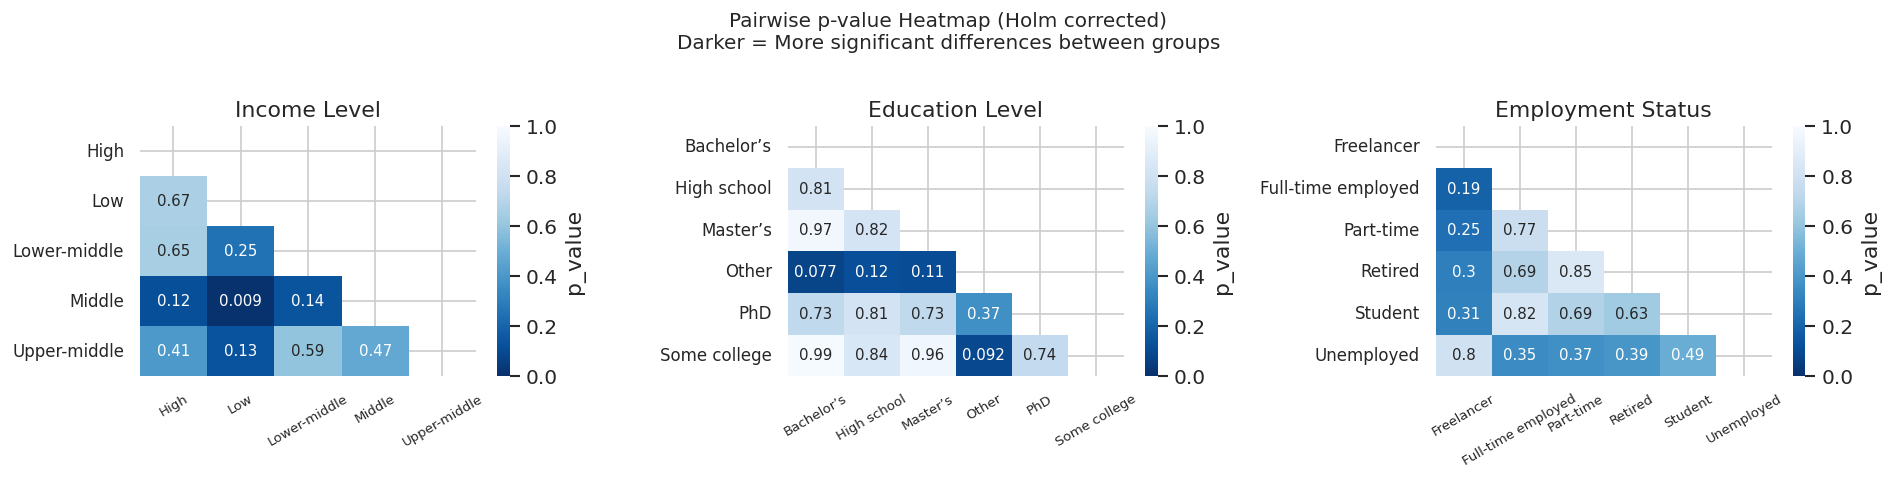

In [ ]:

import matplotlib.colors as mcolors

bounds = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 1]

norm = mcolors.BoundaryNorm(bounds, ncolors = 256)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label, _) in zip(axes, cat_vars):
  testing = all_pairwise[all_pairwise['Contrast'] == col][['A', 'B', 'p_unc']]
  pivot = testing.pivot(index = 'B', columns = 'A', values = 'p_unc').round(3)

  pivot = pivot.combine_first(pivot.T)
  mask = np.triu(np.ones_like(pivot, dtype = bool))

  sns.heatmap(pivot, annot = True, linecolor = 'white',
              annot_kws = {'size': 9}, cbar_kws = {'label': 'p_value'},
              ax = ax, cmap = 'Blues_r', mask = mask,
              vmin = 0, vmax = 1)

  ax.set_title(label)
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 30, fontsize = 8)
  ax.set_yticklabels(ax.get_yticklabels(), fontsize = 10)


  fig.suptitle('Pairwise p-value Heatmap (Holm corrected)\nDarker = More significant differences between groups',
             fontsize = 12, fontweight = '500', y = 1)

plt.tight_layout()
plt.show()

| **Hypothesis** | **Methods Used** | **Findings** |
|----------------|------------------|--------------|
| **1** | <ul><li>D'Agostino–Pearson normality test (`stats.normaltest`)</li><li>Levene's test for equality of variances (`stats.levene`)</li><li>Independent t-test (`stats.ttest_ind`)</li><li>Cohen's *d* (effect size)</li><li>Mann–Whitney U test (`stats.mannwhitneyu`)</li><li>Rank-biserial correlation (effect size)</li><li>Bootstrap confidence interval</li></ul> | <ul><li>All tested variables produced statistically significant p-values, indicating departures from normality.</li><li>The average difference was approximately **17**, and the confidence interval remained above **0**, indicating a statistically significant difference.</li><li>Both the t-test and Mann–Whitney U test confirmed a statistically significant difference between the two groups.</li><li>Both Cohen's *d* and the rank-biserial correlation indicated a meaningful effect size.</li><li>The bootstrap confidence interval did not include **0**, further supporting the significance of the difference.</li></ul> |
| **2** | <ul><li>Multiple Ordinary Least Squares (OLS) regression (`smf.ols`)</li><li>Residual vs. fitted value analysis</li></ul> | <ul><li>The model achieved an **R² of 0.67**, indicating that time spent on **Explore**, **Feed**, and **Sessions** jointly explained approximately **67%** of the variation in stress levels.</li><li>The residual plot showed a downward trend, suggesting the model tends to overestimate higher stress values and underestimate lower stress values.</li></ul> |
| **3** | <ul><li>Multiple Ordinary Least Squares (OLS) regression (`smf.ols`)</li><li>Partial regression (`statsmodels.api.graphics.plot_partregress`)</li></ul> | <ul><li>Among all numeric predictors, **Age** was the only additional variable that significantly improved the prediction of stress levels.</li><li>Including age increased the model's **R² to over 0.69**.</li><li>Age contributed meaningfully only when considered alongside the social media usage variables; by itself, it explained little variation in stress.</li><li>The partial regression plot confirmed a positive relationship between **Age** and **Stress** after controlling for the other predictors.</li></ul> |
| **4** | <ul><li>Kruskal–Wallis test (`pg.kruskal`)</li><li>Pairwise post-hoc test with Holm correction</li></ul> | <ul><li>None of the socioeconomic variables showed statistically significant differences across groups, providing insufficient evidence that stress levels differ by socioeconomic status.</li><li>The pairwise post-hoc test identified a significant difference between the **Low** and **Middle** income groups. However, because the overall Kruskal–Wallis test was not significant, this isolated result should be interpreted with caution.</li></ul> |

# Appendix

Using the Chi2 Independence Test to check the significance between two categorical data

In [ ]:
tables = pg.chi2_independence(data = df, x = 'high_stress', y = 'heavy_user')
test_table = tables[2]
print(test_table[['test','chi2', 'pval']])

                 test          chi2  pval
0             pearson  23634.354427   0.0
1        cressie-read  24113.236561   0.0
2      log-likelihood  25984.214606   0.0
3       freeman-tukey  28409.906461   0.0
4  mod-log-likelihood  32038.252833   0.0
5              neyman  44975.768440   0.0
